In [37]:
import os, pickle

import numpy as np
import matplotlib.pyplot as plt
import hist
import vector

from datasets import balanced
from models import carl

import torch
from torch.utils.data import DataLoader
import lightning as L

In [38]:
JOBS_DIR = '../jobs'

CARL_DIR = 'qqZZ-vs-SBI-05'
CHECKPOINT = [58, 0.68]

EVENTS_NUM = 'events_num.pkl'
EVENTS_DEN = 'events_den.pkl'

SCALER = 'scaler.pkl'

VERSION = 0

CHECKPOINT_PATH = os.path.join(JOBS_DIR, 'carl', CARL_DIR, 'checkpoints', f'checkpoint-carl-epoch={CHECKPOINT[0]}-val_loss={CHECKPOINT[1]}.ckpt')
EVENTS_NUM_PATH = os.path.join(JOBS_DIR, 'carl', CARL_DIR, EVENTS_NUM)
EVENTS_DEN_PATH = os.path.join(JOBS_DIR, 'carl', CARL_DIR, EVENTS_DEN)
SCALER_PATH = os.path.join(JOBS_DIR, 'carl', CARL_DIR, SCALER)
METRICS_PATH = os.path.join(JOBS_DIR, 'carl', CARL_DIR, 'lightning_logs', f'version_{VERSION}', 'metrics.csv')

In [39]:
SAMPLE_SIZE = 2500000

BATCH_SIZE = 1024

SEED = 42

FEATURES = ['l1_pt', 'l1_eta', 'l1_phi', 'l1_energy',
            'l2_pt', 'l2_eta', 'l2_phi', 'l2_energy',
            'l3_pt', 'l3_eta', 'l3_phi', 'l3_energy',
            'l4_pt', 'l4_eta', 'l4_phi', 'l4_energy']

In [40]:
with open(EVENTS_NUM_PATH, 'rb') as f:
    events_num = pickle.load(f)

with open(EVENTS_DEN_PATH, 'rb') as f:
    events_den = pickle.load(f)

In [41]:
events_numerator_train, events_numerator_val = events_num.shuffle(random_state=SEED).split(train_size=0.5, val_size=0.5)
events_denominator_train, events_denominator_val = events_den.shuffle(random_state=SEED).split(train_size=0.5, val_size=0.5)

training_data = balanced.BalancedDataset(events_numerator_train, events_denominator_train, FEATURES, SAMPLE_SIZE, SEED)
validation_data = balanced.BalancedDataset(events_numerator_val, events_denominator_val, FEATURES, SAMPLE_SIZE, SEED)

with open(SCALER_PATH, 'rb') as f:
    scaler = pickle.load(f)

training_data.X = scaler.transform(training_data.X)
validation_data.X = scaler.transform(validation_data.X)

[[ 1.2810907e+02 -9.5667416e-01  5.4866081e-01  1.9134331e+02
   7.6473900e+01 -1.7305551e+00  2.9339654e+00  2.2257620e+02
   7.2636681e+01 -1.2954012e+00 -2.2165351e+00  1.4259480e+02
   2.6246572e+01 -1.1922512e+00 -1.2111346e+00  4.7217930e+01]
 [ 5.9462940e+01  1.2812089e+00  1.7631010e+00  1.1531920e+02
   5.3894527e+01 -1.8022988e+00 -1.7372184e+00  1.6784070e+02
   3.5083454e+01 -1.0354486e+00  9.0123564e-01  5.5632481e+01
   3.2759178e+01  8.1825715e-01 -1.6160420e+00  4.4351761e+01]
 [ 7.0500916e+01  1.8508986e+00  1.4621352e+00  2.2992580e+02
   5.2858067e+01  3.9845127e-01 -2.0760484e+00  5.7109840e+01
   2.0629059e+01 -1.5899687e+00 -4.3888521e-01  5.2681740e+01
   1.5083519e+01  7.5677112e-02 -1.6195321e+00  1.5126740e+01]
 [ 1.2869228e+02 -8.1439823e-01  4.5557001e-01  1.7378101e+02
   1.1046061e+02  2.0197847e-01 -2.1178746e+00  1.1272140e+02
   6.2736523e+01  8.8091826e-01  3.0842934e+00  8.8694283e+01
   3.4423634e+01  1.5473279e-01  1.4388900e+00  3.4836540e+01]
 [ 5

/home/iwsatlas1/griesemx/ggZZ_work/venv_pytorch/lib64/python3.10/site-packages/sklearn/base.py:299: UserWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.2.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [42]:
metrics = np.genfromtxt(METRICS_PATH, delimiter=',')

epochs = metrics[1::2,0]
steps = metrics[1::2,1]
train_loss = metrics[0::2,2][1:]
val_loss = metrics[1::2,3]

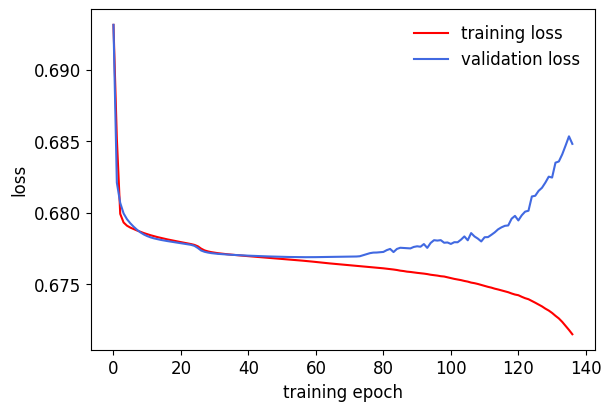

In [43]:
fig = plt.figure(figsize=(6,4), layout='constrained')

plt.plot(epochs, train_loss, color='red', label='training loss')
plt.plot(epochs, val_loss, color='royalblue', label='validation loss')

plt.legend(frameon=False, fontsize=12)
plt.xlabel('training epoch', fontsize=12)
plt.ylabel('loss', fontsize=12)

plt.tick_params(axis='both', labelsize=12)

plt.show()

In [44]:
model = carl.CARL.load_from_checkpoint(CHECKPOINT_PATH)

In [45]:
dl_training = DataLoader(training_data, BATCH_SIZE)
dl_validation = DataLoader(validation_data, BATCH_SIZE)

In [46]:
trainer = L.Trainer(accelerator='cpu')

pred_validation = torch.concatenate(trainer.predict(model, dl_validation)).numpy()

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/iwsatlas1/griesemx/ggZZ_work/venv_pytorch/lib64/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=15` in the `DataLoader` to improve performance.


Predicting DataLoader 0: 100%|██████████| 4883/4883 [37:12<00:00,  2.19it/s]


/home/iwsatlas1/griesemx/ggZZ_work/venv_pytorch/lib64/python3.10/site-packages/numpy/core/_methods.py:265: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/home/iwsatlas1/griesemx/ggZZ_work/venv_pytorch/lib64/python3.10/site-packages/numpy/core/_methods.py:223: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean, casting='unsafe',
/home/iwsatlas1/griesemx/ggZZ_work/venv_pytorch/lib64/python3.10/site-packages/numpy/core/_methods.py:257: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/tmp/ipykernel_371031/3631949064.py:17: RuntimeWarning: invalid value encountered in divide
  truth_ratios = sig_per_bin/(bkg_per_bin + sig_per_bin)
/tmp/ipykernel_371031/3631949064.py:19: RuntimeWarning: invalid value encountered in divide
  truth_ratios_dev = np.sqrt((sig_dev/bkg_per_bin)**2 + (-bkg_dev*sig_per_bin/bkg_per_bin**2)**2)
/home/iws

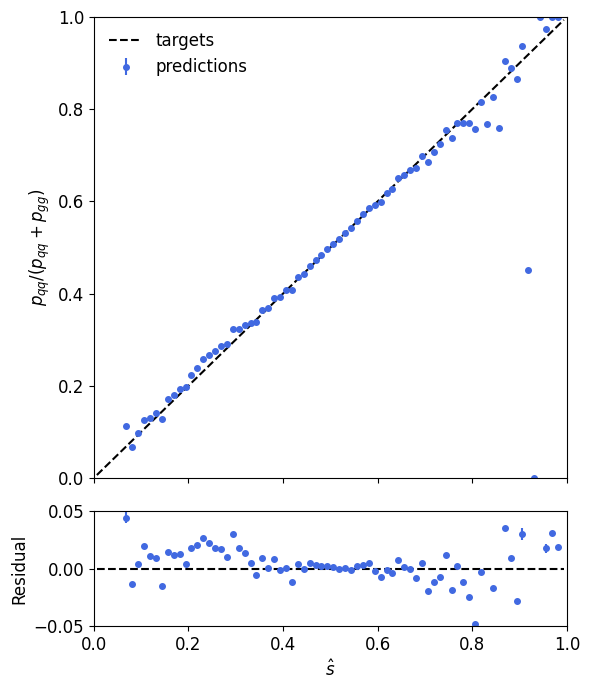

In [ ]:
bins = 80
bounds = [0,1]
step_size = (bounds[1]-bounds[0])/bins

p = pred_validation
t = validation_data.s

targets_binned = [t[(p > bounds[0]+step_size*i) & (p <= bounds[0]+step_size*(i+1))] for i in range(bins)]

sig_per_bin = np.array([np.sum(targets_binned[i]==1.0) for i in range(bins)])
bkg_per_bin = np.array([np.sum(targets_binned[i]==0.0) for i in range(bins)])

sig_dev = np.array([np.std(targets_binned[i]==1.0) for i in range(bins)])
bkg_dev = np.array([np.std(targets_binned[i]==0.0) for i in range(bins)])

truth_ratios = sig_per_bin/(bkg_per_bin + sig_per_bin)

truth_ratios_dev = np.sqrt((sig_dev * bkg_per_bin/(sig_per_bin + bkg_per_bin)**2)**2 + (-bkg_dev*sig_per_bin/(sig_per_bin + bkg_per_bin)**2)**2)

centers = np.array([bounds[0]+(i+1/2)*step_size for i in range(bins)])

fig, (ax1, ax2) = plt.subplots(2,1, gridspec_kw={'height_ratios': [4,1]}, figsize=(6,7))

ax1.set_xticklabels([])

ax1.errorbar(centers, centers, color='black', linestyle='--', label='targets')
ax1.errorbar(centers, truth_ratios, yerr=truth_ratios_dev, color='royalblue', marker='o', markersize=4, linestyle='none', label='predictions')

ax1.set_xlim(*bounds)
ax1.set_ylim(*bounds)
ax1.set_ylabel('$p_{qq}/(p_{qq}+p_{gg})$', fontsize=12)
ax1.tick_params(axis='both', labelsize=12)

ax1.legend(frameon=False, fontsize=12)

ax2.errorbar(centers, np.array(centers)-np.array(centers), color='black', linestyle='--', label='targets')
ax2.errorbar(centers, np.array(truth_ratios)-np.array(centers), yerr=truth_ratios_dev, color='royalblue', marker='o', markersize=4, linestyle='none', label='predictions')

ax2.set_xlim(*bounds)
ax2.set_xlabel('$\hat{s}$', fontsize=12)
ax2.set_ylabel('Residual', fontsize=12)
ax2.set_ylim(-5e-2,5e-2)
ax2.tick_params(axis='both', labelsize=12)

plt.tight_layout()
plt.show()

In [49]:
sorted_indices = np.empty(2*SAMPLE_SIZE)
sorted_indices[validation_data.indices] = np.arange(2*SAMPLE_SIZE)
sorted_indices = sorted_indices.astype(int)

In [50]:
validation_data_unscaled = scaler.inverse_transform(validation_data.X)

l1 = vector.array({"pt": validation_data_unscaled[:,0], "eta": validation_data_unscaled[:,1], "phi": validation_data_unscaled[:,2], "energy": validation_data_unscaled[:,3]})
l2 = vector.array({"pt": validation_data_unscaled[:,4], "eta": validation_data_unscaled[:,5], "phi": validation_data_unscaled[:,6], "energy": validation_data_unscaled[:,7]})
l3 = vector.array({"pt": validation_data_unscaled[:,8], "eta": validation_data_unscaled[:,9], "phi": validation_data_unscaled[:,10], "energy": validation_data_unscaled[:,11]})
l4 = vector.array({"pt": validation_data_unscaled[:,12], "eta": validation_data_unscaled[:,13], "phi": validation_data_unscaled[:,14], "energy": validation_data_unscaled[:,15]})

In [51]:
m4l_numerator = (l1+l2+l3+l4).mass[sorted_indices][:SAMPLE_SIZE]
m4l_denominator = (l1+l2+l3+l4).mass[sorted_indices][SAMPLE_SIZE:]

In [52]:
pred_sorted_val = pred_validation[sorted_indices]

/tmp/ipykernel_371031/1384200864.py:32: RuntimeWarning: invalid value encountered in divide
  ax2.errorbar(h_true.axes[0].centers, h_true.values()/h_ggZZ.values(), yerr=np.sqrt((np.sqrt(h_true.variances())/h_ggZZ.values())**2 + (-np.sqrt(h_ggZZ.variances())*h_true.values()/h_ggZZ.values()**2)**2), color='royalblue', drawstyle='steps-mid', label=f'Truth qqZZ', alpha=0.8)
/tmp/ipykernel_371031/1384200864.py:33: RuntimeWarning: invalid value encountered in divide
  ax2.errorbar(h_reweight.axes[0].centers, h_reweight.values()/h_ggZZ.values(), yerr=np.sqrt((np.sqrt(h_reweight.variances())/h_ggZZ.values())**2 + (-np.sqrt(h_ggZZ.variances())*h_reweight.values()/h_ggZZ.values()**2)**2), color='r', drawstyle='steps-mid', label=f'CARL ggZZ->qqZZ')
/tmp/ipykernel_371031/1384200864.py:46: RuntimeWarning: invalid value encountered in divide
  ax3.errorbar(h_true.axes[0].centers, h_true.values()/h_true.values(), yerr=np.sqrt(h_true.variances())/h_true.values(), color='royalblue', drawstyle='steps-mi

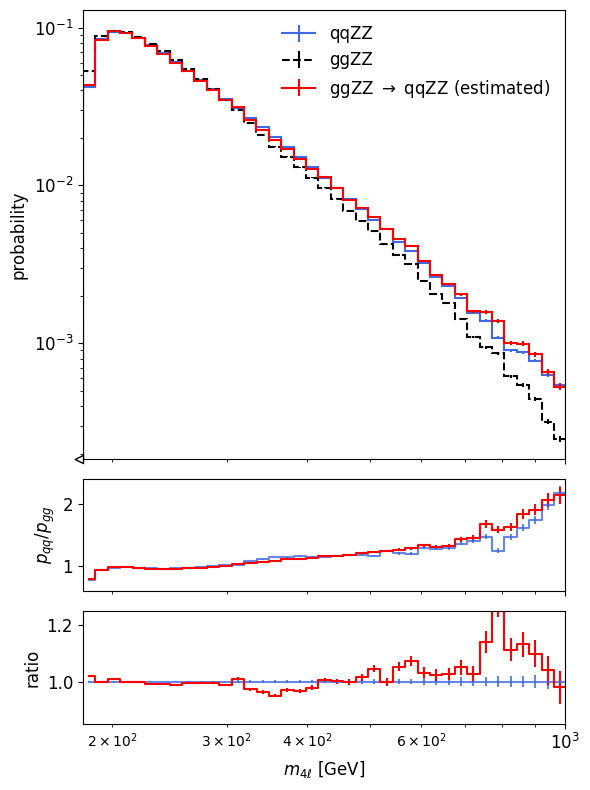

In [56]:
bins = 40
bounds = [180,1050]

h_true = hist.Hist(hist.axis.Regular(bins, *bounds, transform=hist.axis.transform.log), storage=hist.storage.Weight())
h_true.fill(m4l_numerator, weight=np.ones(SAMPLE_SIZE)*1/SAMPLE_SIZE)

h_ggZZ = hist.Hist(hist.axis.Regular(bins, *bounds, transform=hist.axis.transform.log), storage=hist.storage.Weight())
h_ggZZ.fill(m4l_denominator, weight=np.ones(SAMPLE_SIZE)*1/SAMPLE_SIZE)


h_reweight = hist.Hist(hist.axis.Regular(bins, *bounds, transform=hist.axis.transform.log), storage=hist.storage.Weight())
h_reweight.fill(m4l_denominator, weight=np.ones(SAMPLE_SIZE)*1/SAMPLE_SIZE*pred_sorted_val[SAMPLE_SIZE:]/(1-pred_sorted_val[SAMPLE_SIZE:]))

fig, (ax1, ax2, ax3) = plt.subplots(3,1,gridspec_kw={'height_ratios': [4, 1, 1]},figsize=(6,8), layout='constrained')

h_true.plot(ax=ax1,color='royalblue', label='qqZZ')
h_ggZZ.plot(ax=ax1,color='black', linestyle='--', label='ggZZ')
h_reweight.plot(ax=ax1,color='red', label='ggZZ $\\rightarrow$ qqZZ (estimated)')

ax1.set_xlabel('')
ax1.set_ylabel('probability', fontsize=12)
ax1.set_xlim(180,1000)
ax1.set_xscale('log')

ax1.set_xticklabels([])
ax1.tick_params(labelsize=12)
ax1.xaxis.set_tick_params(which='minor', labelleft=False, labelright=False)

ax1.set_yscale('log')
ax1.legend(frameon=False, fontsize=12)

ax2.errorbar(h_true.axes[0].centers, h_true.values()/h_ggZZ.values(), yerr=np.sqrt((np.sqrt(h_true.variances())/h_ggZZ.values())**2 + (-np.sqrt(h_ggZZ.variances())*h_true.values()/h_ggZZ.values()**2)**2), color='royalblue', drawstyle='steps-mid', label=f'Truth qqZZ', alpha=0.8)
ax2.errorbar(h_reweight.axes[0].centers, h_reweight.values()/h_ggZZ.values(), yerr=np.sqrt((np.sqrt(h_reweight.variances())/h_ggZZ.values())**2 + (-np.sqrt(h_ggZZ.variances())*h_reweight.values()/h_ggZZ.values()**2)**2), color='r', drawstyle='steps-mid', label=f'CARL ggZZ->qqZZ')

ax2.tick_params(labelsize=12)

ax2.set_ylabel('$p_{qq}/p_{gg}$', fontsize=12)
ax2.set_xlim(180,1000)
ax2.set_ylim(0.6,2.4)
ax2.set_xscale('log')
ax2.xaxis.set_tick_params(which='minor', labelleft=False, labelright=False)

ax2.set_xlabel('')
ax2.set_xticklabels([])

ax3.errorbar(h_true.axes[0].centers, h_true.values()/h_true.values(), yerr=np.sqrt(h_true.variances())/h_true.values(), color='royalblue', drawstyle='steps-mid', label=f'Truth qqZZ', alpha=0.8)
ax3.errorbar(h_reweight.axes[0].centers, h_reweight.values()/h_true.values(), yerr=np.sqrt((np.sqrt(h_reweight.variances())/h_true.values())**2 + (-np.sqrt(h_true.variances())*h_reweight.values()/h_true.values()**2)**2), color='r', drawstyle='steps-mid', label=f'CARL ggZZ->qqZZ')

ax3.tick_params(labelsize=12)

ax3.set_xlabel('$m_{4\ell}$ [GeV]', fontsize=12)
ax3.set_ylabel('ratio', fontsize=12)
ax3.set_xlim(180,1000)
ax3.set_ylim(0.85,1.25)
ax3.set_xscale('log')

plt.tight_layout()

plt.show()